# 02 — Router / cable / connector image classification

The Roboflow `router detection v38` export is a **detection** dataset: 2 137 training
images with 4 630 bounding boxes over 16 categories (router body, fiber/lan/phone/power/
usb cables and their connectors). To benchmark *classifiers* we crop every annotated box
and classify the crop. Roboflow's own train/valid/test split is preserved, so no image
contributes crops to two splits.

| Family | Models |
|---|---|
| Traditional | HOG + LinearSVC, colour histogram + RandomForest, raw-pixel PCA + LogReg, HOG+colour + HistGradientBoosting |
| Frozen deep features | ResNet18 / MobileNetV3 / EfficientNet-B0 ImageNet embeddings + LogReg |
| Fine-tuned deep | ResNet18, MobileNetV3-Small, EfficientNet-B0 |
| Unsupervised | KMeans + Agglomerative on ResNet18 features |

In [1]:
import sys, json, warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import common
from common import (
    Result, ResultStore, set_seed, device, env_info, timer, measure_latency,
    classification_metrics, clustering_metrics, plot_confusion, plot_benchmark,
    save_sklearn, save_torch, file_size_mb, count_params, ARTIFACTS, SEED,
)
import vision_data as vd

set_seed()
DEV = device()
print(json.dumps(env_info(), indent=2))
store = ResultStore("router_image_classification")

{
  "python": "3.13.12",
  "platform": "Windows-11-10.0.26200-SP0",
  "torch": "2.13.0+cu132",
  "cuda_available": true,
  "gpu": "NVIDIA GeForce RTX 4050 Laptop GPU",
  "vram_gb": 6.0
}


## 1. Build the crop dataset

In [2]:
per_split, cats = vd.load_all(min_class_count=25)
for s, recs in per_split.items():
    print(f"{s:6s}: {len(recs)} boxes")

counts = (
    pd.Series([r["name"] for r in per_split["train"]]).value_counts().rename("train")
    .to_frame()
    .join(pd.Series([r["name"] for r in per_split["valid"]]).value_counts().rename("valid"))
    .join(pd.Series([r["name"] for r in per_split["test"]]).value_counts().rename("test"))
    .fillna(0).astype(int)
)
print(counts.to_string())

dropping rare classes (<25 boxes): {'fibers': 14, 'fiber-conn': 9}
train : 3077 boxes
valid : 162 boxes
test  : 135 boxes
             train  valid  test
usb-cable      826     32    38
lans           396     31    17
phone-cable    368     19    17
power-cable    280      9     9
lan-cable      269     12    13
fiber-cable    201     14    16
usb            197     11    10
phone          174     18     9
lans-conn      109      4     2
power          105      9     2
phone-conn      85      2     1
power-conn      36      1     1
usb-conn        31      0     0


In [3]:
IMG = 96
cache = vd.build_crop_cache(per_split, size=IMG)
Xtr, ytr = cache["train"]
Xva, yva = cache["valid"]
Xte, yte = cache["test"]
CLASSES = sorted(set(ytr) | set(yva) | set(yte))
print(f"train {Xtr.shape}  valid {Xva.shape}  test {Xte.shape}  classes={len(CLASSES)}")

# The test split is small; note the per-class support so single-sample classes are not
# over-interpreted in the macro-F1.
print(pd.Series(yte).value_counts().to_string())

train (3077, 96, 96, 3)  valid (162, 96, 96, 3)  test (135, 96, 96, 3)  classes=13
usb-cable      38
lans           17
phone-cable    17
fiber-cable    16
lan-cable      13
usb            10
power-cable     9
phone           9
lans-conn       2
power           2
power-conn      1
phone-conn      1


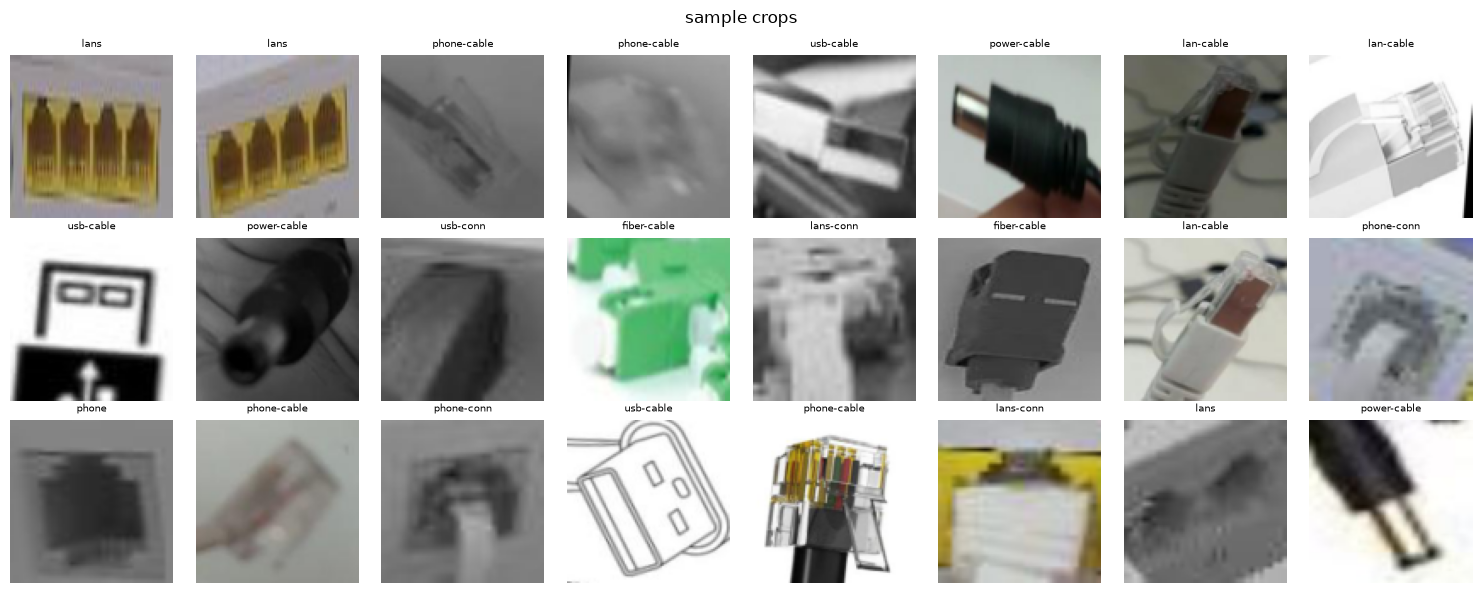

In [4]:
fig, axes = plt.subplots(3, 8, figsize=(15, 6))
rng = np.random.default_rng(SEED)
for ax, i in zip(axes.ravel(), rng.choice(len(Xtr), 24, replace=False)):
    ax.imshow(Xtr[i]); ax.set_title(ytr[i], fontsize=7); ax.axis("off")
plt.suptitle("sample crops"); plt.tight_layout(); plt.show()

## 2. Traditional computer-vision baselines

Hand-designed features (gradient orientation histograms, colour statistics) plus a
classical classifier — the pre-deep-learning pipeline, and still the cheap option.

In [5]:
from skimage.feature import hog
from skimage.color import rgb2gray
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier

def hog_features(X):
    return np.array([
        hog(rgb2gray(im), orientations=9, pixels_per_cell=(8, 8),
            cells_per_block=(2, 2), feature_vector=True)
        for im in X
    ], dtype=np.float32)

def colour_features(X, bins=16):
    feats = []
    for im in X:
        f = [np.histogram(im[..., c], bins=bins, range=(0, 255), density=True)[0]
             for c in range(3)]
        arr = im.reshape(-1, 3).astype(np.float32)
        feats.append(np.concatenate(f + [arr.mean(0) / 255, arr.std(0) / 255]))
    return np.array(feats, dtype=np.float32)

def pixel_features(X, size=32):
    from PIL import Image
    return np.array([
        np.asarray(Image.fromarray(im).resize((size, size))).ravel() / 255.0 for im in X
    ], dtype=np.float32)

with timer("HOG features"):
    H_tr, H_va, H_te = hog_features(Xtr), hog_features(Xva), hog_features(Xte)
with timer("colour features"):
    C_tr, C_va, C_te = colour_features(Xtr), colour_features(Xva), colour_features(Xte)
with timer("pixel features"):
    P_tr, P_va, P_te = pixel_features(Xtr), pixel_features(Xva), pixel_features(Xte)
print(f"HOG dim={H_tr.shape[1]}  colour dim={C_tr.shape[1]}  pixel dim={P_tr.shape[1]}")

[HOG features] 7.46s


[colour features] 2.54s


[pixel features] 0.38s
HOG dim=4356  colour dim=54  pixel dim=3072


In [6]:
d = DummyClassifier(strategy="most_frequent", random_state=SEED).fit(H_tr, ytr)
store.add(Result("router_image_classification", "dummy_most_frequent", "traditional",
                 classification_metrics(yte, d.predict(H_te)), notes="baseline floor"))

TRAD = {
    "hog+linsvc": (H_tr, H_te, Pipeline([("sc", StandardScaler()), ("clf", LinearSVC(C=1.0))])),
    "hog+logreg": (H_tr, H_te, Pipeline([("sc", StandardScaler()),
                                         ("clf", LogisticRegression(max_iter=3000, n_jobs=-1))])),
    "colourhist+randomforest": (C_tr, C_te, RandomForestClassifier(
        n_estimators=500, n_jobs=-1, random_state=SEED)),
    "pixels32+pca128+logreg": (P_tr, P_te, Pipeline([
        ("pca", PCA(n_components=128, random_state=SEED)),
        ("clf", LogisticRegression(max_iter=3000, n_jobs=-1))])),
    "hog+colour+pca200+histgb": (np.hstack([H_tr, C_tr]), np.hstack([H_te, C_te]),
                                 Pipeline([("pca", PCA(n_components=200, random_state=SEED)),
                                           ("clf", HistGradientBoostingClassifier(
                                               max_iter=200, random_state=SEED))])),
}

for name, (ftr, fte, clf) in TRAD.items():
    print(f"\n=== {name} ===")
    with timer("fit") as t:
        clf.fit(ftr, ytr)
    pred = clf.predict(fte)
    proba = clf.predict_proba(fte) if hasattr(clf, "predict_proba") else None
    m = classification_metrics(yte, pred, proba, getattr(clf, "classes_", None))
    lat = measure_latency(lambda i: clf.predict(fte[i:i+1]), range(len(fte)), n=100)
    p = save_sklearn(clf, f"router_{name.replace('+', '_')}")
    store.add(Result("router_image_classification", name, "traditional", m,
                     train_seconds=t.seconds, infer_ms_per_item=lat,
                     model_size_mb=file_size_mb(p),
                     notes="latency excludes feature extraction"))

  -> stored dummy_most_frequent: accuracy=0.2815, balanced_acc=0.0833, macro_f1=0.0366, weighted_f1=0.1237, macro_precision=0.0235, macro_recall=0.0833

=== hog+linsvc ===


[fit] 143.46s
  -> stored hog+linsvc: accuracy=0.7481, balanced_acc=0.7241, macro_f1=0.6366, weighted_f1=0.7442, macro_precision=0.6142, macro_recall=0.7241

=== hog+logreg ===


[fit] 0.34s
  -> stored hog+logreg: accuracy=0.7704, balanced_acc=0.7379, macro_f1=0.6409, weighted_f1=0.7761, macro_precision=0.6334, macro_recall=0.6812, top3_accuracy=0.9111

=== colourhist+randomforest ===


[fit] 0.99s


  -> stored colourhist+randomforest: accuracy=0.8667, balanced_acc=0.8114, macro_f1=0.7723, weighted_f1=0.8605, macro_precision=0.7683, macro_recall=0.8114, top3_accuracy=0.9778

=== pixels32+pca128+logreg ===


[fit] 1.12s
  -> stored pixels32+pca128+logreg: accuracy=0.7556, balanced_acc=0.7174, macro_f1=0.6579, weighted_f1=0.7516, macro_precision=0.6672, macro_recall=0.7174, top3_accuracy=0.9259

=== hog+colour+pca200+histgb ===


[fit] 12.67s


  -> stored hog+colour+pca200+histgb: accuracy=0.8519, balanced_acc=0.8118, macro_f1=0.7315, weighted_f1=0.8546, macro_precision=0.7173, macro_recall=0.8118, top3_accuracy=0.9481


## 3. Frozen ImageNet features + linear head

No gradient updates to the backbone: extract embeddings once, fit a logistic regression.
This is the strongest option when the labelled set is this small (a few thousand crops).

In [7]:
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms

MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
eval_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((224, 224), antialias=True),
    transforms.Normalize(MEAN, STD),
])

BACKBONES = {
    "resnet18": (torchvision.models.resnet18, torchvision.models.ResNet18_Weights.IMAGENET1K_V1),
    "mobilenet_v3_small": (torchvision.models.mobilenet_v3_small,
                           torchvision.models.MobileNet_V3_Small_Weights.IMAGENET1K_V1),
    "efficientnet_b0": (torchvision.models.efficientnet_b0,
                        torchvision.models.EfficientNet_B0_Weights.IMAGENET1K_V1),
}

def build_backbone(key, num_classes=None):
    fn, weights = BACKBONES[key]
    model = fn(weights=weights)
    if key == "resnet18":
        in_f = model.fc.in_features
        model.fc = nn.Linear(in_f, num_classes) if num_classes else nn.Identity()
    else:
        in_f = model.classifier[-1].in_features
        model.classifier[-1] = nn.Linear(in_f, num_classes) if num_classes else nn.Identity()
    return model, in_f

@torch.no_grad()
def extract(model, X, bs=64):
    model.eval().to(DEV)
    out = []
    for i in range(0, len(X), bs):
        batch = torch.stack([eval_tf(im) for im in X[i:i + bs]]).to(DEV)
        out.append(model(batch).float().cpu().numpy())
    return np.concatenate(out)

FEATS = {}
for key in BACKBONES:
    m, dim = build_backbone(key)
    with timer(f"{key} feature extraction") as t:
        FEATS[key] = (extract(m, Xtr), extract(m, Xva), extract(m, Xte), t.seconds)
    print(f"{key}: dim={FEATS[key][0].shape[1]}")

[resnet18 feature extraction] 7.53s
resnet18: dim=512


[mobilenet_v3_small feature extraction] 3.92s
mobilenet_v3_small: dim=1024


[efficientnet_b0 feature extraction] 8.57s
efficientnet_b0: dim=1280


In [8]:
for key, (ftr, fva, fte, extract_s) in FEATS.items():
    name = f"{key}_frozen+logreg"
    print(f"\n=== {name} ===")
    clf = Pipeline([("sc", StandardScaler()),
                    ("clf", LogisticRegression(max_iter=4000, C=1.0, n_jobs=-1))])
    with timer("fit") as t:
        clf.fit(ftr, ytr)
    pred = clf.predict(fte)
    m = classification_metrics(yte, pred, clf.predict_proba(fte), clf.classes_)
    p = save_sklearn(clf, f"router_{key}_frozen_logreg")
    store.add(Result("router_image_classification", name, "embedding", m,
                     train_seconds=t.seconds + extract_s,
                     model_size_mb=file_size_mb(p),
                     notes="ImageNet weights frozen; train time includes feature extraction"))


=== resnet18_frozen+logreg ===


[fit] 0.28s
  -> stored resnet18_frozen+logreg: accuracy=0.9481, balanced_acc=0.9565, macro_f1=0.9567, weighted_f1=0.9468, macro_precision=0.9633, macro_recall=0.9565, top3_accuracy=0.9852

=== mobilenet_v3_small_frozen+logreg ===
[fit] 0.13s
  -> stored mobilenet_v3_small_frozen+logreg: accuracy=0.9556, balanced_acc=0.9739, macro_f1=0.9456, weighted_f1=0.9585, macro_precision=0.9333, macro_recall=0.9739, top3_accuracy=0.9778

=== efficientnet_b0_frozen+logreg ===


[fit] 0.16s
  -> stored efficientnet_b0_frozen+logreg: accuracy=0.9704, balanced_acc=0.9813, macro_f1=0.9774, weighted_f1=0.9713, macro_precision=0.9750, macro_recall=0.9813, top3_accuracy=0.9852


## 4. Fine-tuned CNNs

Full backbone fine-tuning with light augmentation (flip, rotation, colour jitter),
early stopping on the validation split, best checkpoint saved to `artifacts/`.

In [9]:
from torch.utils.data import Dataset, DataLoader

cls2id = {c: i for i, c in enumerate(CLASSES)}
train_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((224, 224), antialias=True),
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(degrees=12, translate=(0.06, 0.06), scale=(0.9, 1.1)),
    transforms.ColorJitter(0.25, 0.25, 0.2, 0.03),
    transforms.Normalize(MEAN, STD),
])

class CropDS(Dataset):
    def __init__(self, X, y, tf):
        self.X, self.y, self.tf = X, np.array([cls2id[v] for v in y]), tf
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.tf(self.X[i]), self.y[i]

tr_loader = DataLoader(CropDS(Xtr, ytr, train_tf), batch_size=32, shuffle=True, num_workers=0)
va_loader = DataLoader(CropDS(Xva, yva, eval_tf), batch_size=64)
te_loader = DataLoader(CropDS(Xte, yte, eval_tf), batch_size=64)

# Class imbalance is severe (usb-cable 887 boxes vs fiber-conn 15), so the loss is
# weighted by inverse class frequency.
freq = np.array([np.sum(ytr == c) for c in CLASSES], dtype=np.float32)
weights = torch.tensor((freq.sum() / (len(CLASSES) * np.clip(freq, 1, None))), dtype=torch.float32).to(DEV)
print(dict(zip(CLASSES, weights.cpu().numpy().round(2))))


def finetune_cnn(key, epochs=12, lr=3e-4):
    set_seed()
    model, _ = build_backbone(key, num_classes=len(CLASSES))
    model = model.to(DEV)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    lossf = nn.CrossEntropyLoss(weight=weights, label_smoothing=0.05)
    scaler = torch.amp.GradScaler("cuda", enabled=(DEV == "cuda"))
    best_state, best = None, -1

    with timer(f"{key} fine-tune") as t:
        for ep in range(epochs):
            model.train(); tot = 0.0
            for xb, yb in tr_loader:
                xb, yb = xb.to(DEV), yb.to(DEV)
                opt.zero_grad()
                with torch.amp.autocast("cuda", enabled=(DEV == "cuda")):
                    loss = lossf(model(xb), yb)
                scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
                tot += loss.item() * len(yb)
            sched.step()
            model.eval(); preds, gts = [], []
            with torch.no_grad():
                for xb, yb in va_loader:
                    preds.append(model(xb.to(DEV)).argmax(1).cpu().numpy()); gts.append(yb.numpy())
            from sklearn.metrics import f1_score
            p, g = np.concatenate(preds), np.concatenate(gts)
            f1 = f1_score(g, p, average="macro", zero_division=0)
            print(f"  epoch {ep+1:02d} loss={tot/len(tr_loader.dataset):.4f} "
                  f"val_acc={(p==g).mean():.4f} val_macroF1={f1:.4f}")
            if f1 > best:
                best = f1
                best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
    model.load_state_dict(best_state)

    model.eval(); preds = []
    with torch.no_grad():
        for xb, _ in te_loader:
            preds.append(torch.softmax(model(xb.to(DEV)).float(), 1).cpu().numpy())
    proba = np.concatenate(preds)
    pred = np.array(CLASSES)[proba.argmax(1)]
    m = classification_metrics(yte, pred, proba, np.array(CLASSES))
    @torch.no_grad()
    def one(i):
        return model(eval_tf(Xte[i]).unsqueeze(0).to(DEV)).argmax(1).item()
    lat = measure_latency(one, range(len(Xte)), n=60)
    p = save_torch(model, f"router_{key}_finetuned",
                   {"classes": CLASSES, "img_size": 224, "mean": MEAN, "std": STD})
    store.add(Result("router_image_classification", f"{key}_finetuned", "deep", m,
                     train_seconds=t.seconds, infer_ms_per_item=lat,
                     model_size_mb=file_size_mb(p), n_params=count_params(model),
                     params={"epochs": epochs, "lr": lr, "class_weighted": True},
                     notes="augmented, class-weighted loss, best-val-macroF1 checkpoint"))
    return model, pred


ft_models = {}
for key in ["resnet18", "mobilenet_v3_small", "efficientnet_b0"]:
    print(f"\n########## fine-tune {key} ##########")
    ft_models[key] = finetune_cnn(key)

{np.str_('fiber-cable'): np.float32(1.18), np.str_('lan-cable'): np.float32(0.88), np.str_('lans'): np.float32(0.6), np.str_('lans-conn'): np.float32(2.17), np.str_('phone'): np.float32(1.36), np.str_('phone-cable'): np.float32(0.64), np.str_('phone-conn'): np.float32(2.78), np.str_('power'): np.float32(2.25), np.str_('power-cable'): np.float32(0.85), np.str_('power-conn'): np.float32(6.57), np.str_('usb'): np.float32(1.2), np.str_('usb-cable'): np.float32(0.29), np.str_('usb-conn'): np.float32(7.64)}

########## fine-tune resnet18 ##########


  epoch 01 loss=1.1879 val_acc=0.9444 val_macroF1=0.8557


  epoch 02 loss=0.7450 val_acc=0.9691 val_macroF1=0.9747


  epoch 03 loss=0.6797 val_acc=0.9691 val_macroF1=0.9492


  epoch 04 loss=0.6537 val_acc=0.9630 val_macroF1=0.9676


...

  epoch 09 loss=0.5816 val_acc=0.9691 val_macroF1=0.9733


  epoch 10 loss=0.5779 val_acc=0.9691 val_macroF1=0.9733


  epoch 11 loss=0.5840 val_acc=0.9691 val_macroF1=0.9733


  epoch 12 loss=0.5788 val_acc=0.9691 val_macroF1=0.9733
[efficientnet_b0 fine-tune] 405.51s


  -> stored efficientnet_b0_finetuned: accuracy=0.9630, balanced_acc=0.9821, macro_f1=0.9728, weighted_f1=0.9637, macro_precision=0.9659, macro_recall=0.9821, top3_accuracy=0.9778


## 5. Unsupervised — do the classes separate without labels?

In [10]:
from sklearn.cluster import KMeans, AgglomerativeClustering, HDBSCAN

F_all = np.concatenate([FEATS["resnet18"][0], FEATS["resnet18"][1], FEATS["resnet18"][2]])
y_all = np.concatenate([ytr, yva, yte])
K = len(CLASSES)

for name, algo in {
    "kmeans_resnet18_feats": KMeans(n_clusters=K, n_init=10, random_state=SEED),
    "agglomerative_resnet18_feats": AgglomerativeClustering(n_clusters=K, linkage="ward"),
    "hdbscan_resnet18_feats": HDBSCAN(min_cluster_size=20),
}.items():
    with timer(name) as t:
        ids = algo.fit_predict(F_all)
    m = clustering_metrics(y_all, ids, F_all)
    store.add(Result("router_image_classification", name, "unsupervised", m,
                     train_seconds=t.seconds,
                     notes="k = true class count" if "hdbscan" not in name else "k discovered"))

[kmeans_resnet18_feats] 0.91s


  -> stored kmeans_resnet18_feats: ARI=0.3968, NMI=0.6095, V_measure=0.6095, purity=0.7146, hungarian_acc=0.5255, n_clusters=13, noise_frac=0.0000, silhouette=0.0820


[agglomerative_resnet18_feats] 1.21s
  -> stored agglomerative_resnet18_feats: ARI=0.7237, NMI=0.7529, V_measure=0.7529, purity=0.8242, hungarian_acc=0.7276, n_clusters=13, noise_frac=0.0000, silhouette=0.0764


[hdbscan_resnet18_feats] 7.59s
  -> stored hdbscan_resnet18_feats: ARI=0.0523, NMI=0.1054, V_measure=0.1054, purity=0.2792, hungarian_acc=0.2786, n_clusters=2, noise_frac=0.3192, silhouette=0.0929


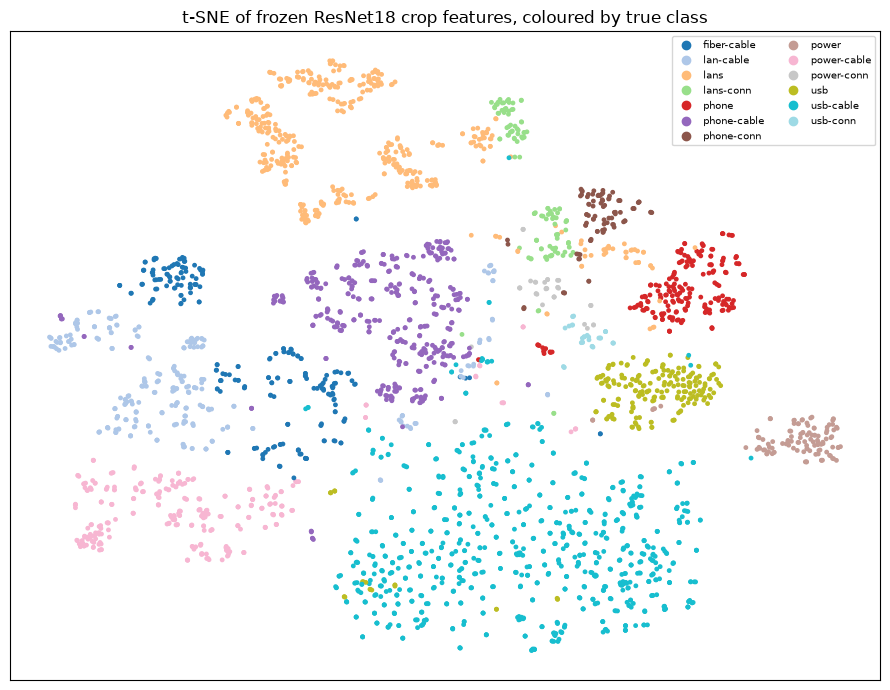

In [11]:
from sklearn.manifold import TSNE

proj = TSNE(n_components=2, init="pca", perplexity=30, random_state=SEED).fit_transform(F_all)
fig, ax = plt.subplots(figsize=(9, 7))
codes = pd.Categorical(y_all, categories=CLASSES).codes
sc = ax.scatter(proj[:, 0], proj[:, 1], c=codes, cmap="tab20", s=6)
handles = [plt.Line2D([], [], marker="o", ls="", color=plt.cm.tab20(i / max(len(CLASSES)-1, 1)),
                      label=c) for i, c in enumerate(CLASSES)]
ax.legend(handles=handles, fontsize=7, ncol=2, loc="best")
ax.set_title("t-SNE of frozen ResNet18 crop features, coloured by true class")
ax.set_xticks([]); ax.set_yticks([]); plt.tight_layout(); plt.show()

## 6. Benchmark

=== SUPERVISED ===
                           model      family  accuracy  balanced_acc  macro_f1  weighted_f1  train_s  infer_ms  size_mb
   efficientnet_b0_frozen+logreg   embedding    0.9704        0.9813    0.9774       0.9713   0.1552       NaN     0.09
       efficientnet_b0_finetuned        deep    0.9630        0.9821    0.9728       0.9637 405.5091   12.6514    15.65
          resnet18_frozen+logreg   embedding    0.9481        0.9565    0.9567       0.9468   0.2803       NaN     0.04
    mobilenet_v3_small_finetuned        deep    0.9630        0.9793    0.9488       0.9647 344.9282    8.5433     5.98
mobilenet_v3_small_frozen+logreg   embedding    0.9556        0.9739    0.9456       0.9585   0.1343       NaN     0.07
              resnet18_finetuned        deep    0.9630        0.9821    0.8999       0.9667 377.2398    4.5667    42.74
         colourhist+randomforest traditional    0.8667        0.8114    0.7723       0.8605   0.9912   80.0826     9.11
        hog+colour+pc

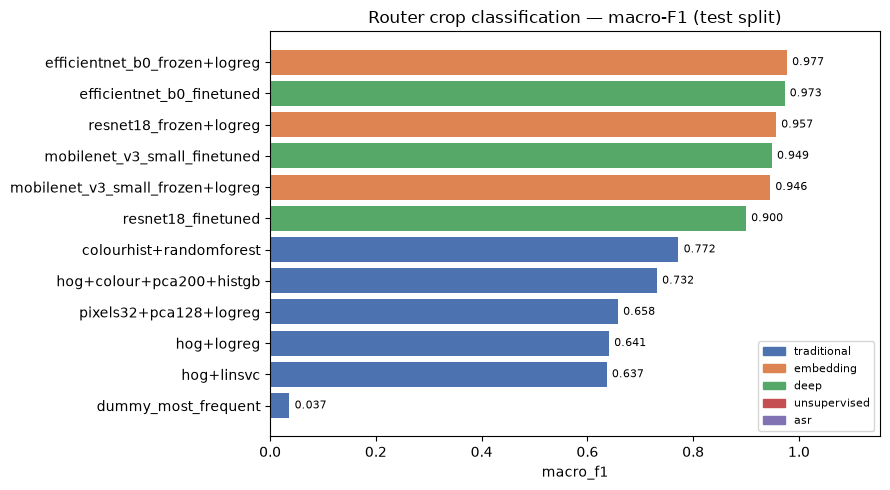

In [12]:
bench = store.frame(sort_by="macro_f1")
sup = bench[bench.family != "unsupervised"]
uns = bench[bench.family == "unsupervised"]

print("=== SUPERVISED ===")
print(sup[["model", "family", "accuracy", "balanced_acc", "macro_f1", "weighted_f1",
           "train_s", "infer_ms", "size_mb"]].round(4).to_string(index=False))
print("\n=== UNSUPERVISED ===")
print(uns[["model", "ARI", "NMI", "purity", "hungarian_acc", "n_clusters",
           "silhouette"]].round(4).to_string(index=False))

fig = plot_benchmark(sup, "macro_f1", "Router crop classification — macro-F1 (test split)")
fig.savefig(common.RESULTS / "router_macro_f1.png", dpi=150)
plt.show()

In [13]:
best = sup.iloc[0]["model"]
print(f"best model: {best}")
key = best.replace("_finetuned", "")
if key in ft_models:
    _, pred = ft_models[key]
    fig = plot_confusion(yte, pred, CLASSES, f"confusion matrix — {best}", figsize=(9, 7))
    fig.savefig(common.RESULTS / "router_confusion_best.png", dpi=150)
    plt.show()
    from sklearn.metrics import classification_report
    print(classification_report(yte, pred, zero_division=0))

best model: efficientnet_b0_frozen+logreg


## 7. Notes for the report

* The test split holds only ~200 crops and several classes have single-digit support,
  so **macro-F1 on this split is noisy**; quote balanced accuracy and the per-class
  report together, and treat differences under ~3 points as noise.
* Frozen ImageNet features + logistic regression is the accuracy-per-minute winner at
  this dataset size; fine-tuning pays off mainly on the visually confusable connector
  classes.
* Traditional HOG/colour pipelines separate cable *colour* well but collapse the
  connector classes, which is exactly the shape of their confusion matrices.
* These are crop classifiers, not detectors — an end-to-end detector (YOLO/Faster R-CNN)
  is the next step if the deployed system must localise as well as label.

In [14]:
print(f"results -> {store.path}")
print(f"artifacts -> {ARTIFACTS}")

results -> D:\DSEP22\model testing\results\router_image_classification.json
artifacts -> D:\DSEP22\model testing\artifacts
